# Optimalizace hyperparametrů v Pythonu: GridSearchCV, RandomizedSearchCV & Hyperopt
Tento notebook demonstruje 3 klíčové techniky vyhledávání optimálních hyperparametrů pro modely strojového učení na normalizovaném datasetu pacientů s onemocněním páteře (`lumbar_normalized_df.csv`):
1. **GridSearchCV** (Vyčerpávající mřížka v Scikit-learn pro `DecisionTreeClassifier`)
2. **RandomizedSearchCV** (Náhodný výběr ze spojitých distribucí pro `SVC`)
3. **Bayesian Optimization** (Pravděpodobnostní model TPE v knihovně `hyperopt` pro `DecisionTreeClassifier`)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from hyperopt import hp, fmin, tpe, Trials, space_eval

# Nastavení vzhledu grafů
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print("Knihovny úspěšně načteny.")

Knihovny úspěšně načteny.


In [2]:
# Načtení dat (robustní nalezení cesty)
import os
csv_candidates = [
    '02_Classification/lumbar_normalized_df.csv',
    '../02_Classification/lumbar_normalized_df.csv',
    '02_Classification/data/lumbar_normalized_df.csv',
    '../02_Classification/data/lumbar_normalized_df.csv',
]
csv_path = None
for p in csv_candidates:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("Soubor lumbar_normalized_df.csv nebyl nalezen!")

print(f"Načítám: {csv_path}")
df = pd.read_csv(csv_path)
print("Tvar datasetu:", df.shape)
display(df.head(5))

# Oddělení příznaků a cílové proměnné
X = df.drop(columns=['class'])
y = df['class'].astype(int)

# Rozdělení na trénovací a testovací sadu (75/25, stratifikováno)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f"Trénovací sada: {X_train.shape[0]} vzorků (Abnormal: {(y_train == 1).sum()}, Normal: {(y_train == 0).sum()})")
print(f"Testovací sada: {X_test.shape[0]} vzorků (Abnormal: {(y_test == 1).sum()}, Normal: {(y_test == 0).sum()})")

Načítám: 02_Classification/lumbar_normalized_df.csv
Tvar datasetu: (310, 7)


,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,0.477474,0.170850,0.300063,0.306625,0.747508,-0.001927,1
1,0.306835,0.079040,0.196523,0.227795,0.898781,0.035857,1
2,0.473200,0.152745,0.344369,0.320454,0.728616,-0.024270,1
3,0.491613,0.174895,0.314357,0.316718,0.722684,0.079538,1
4,0.384294,0.074613,0.218901,0.309680,0.836173,0.061212,1


Trénovací sada: 232 vzorků (Abnormal: 157, Normal: 75)
Testovací sada: 78 vzorků (Abnormal: 53, Normal: 25)


## 1. Grid Search: `GridSearchCV` (DecisionTreeClassifier)
Definujeme mřížku hyperparametrů pro rozhodovací strom:
- `max_depth`: celá čísla 3 až 19 s krokem 2
- `criterion`: 'entropy', 'gini'
- `max_features`: None, 'log2', 'sqrt'
- Optimalizovaná metrika: `scoring='recall'` (důležité v medicíně pro záchyt nemocných)
- Křížová validace: `cv=5` (5-fold)


In [3]:
# Definice mřížky
params_grid = {
    'max_depth': np.arange(3, 21, 2),
    'criterion': ["entropy", "gini"],
    'max_features': [None, "log2", "sqrt"],
}

# Vytvoření základního modelu a GridSearchCV
model_dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=model_dt,
    param_grid=params_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    return_train_score=True
)

# Trénování
grid_search.fit(X_train, y_train)

print("Nejlepší nalezené parametry:")
print(grid_search.best_params_)
print(f"Nejlepší průměrný validační Recall (5-Fold CV): {grid_search.best_score_:.4f}")

Nejlepší nalezené parametry:
{'criterion': 'gini', 'max_depth': 11, 'max_features': 'log2'}
Nejlepší průměrný validační Recall (5-Fold CV): 0.8474


Classification Report pro nejlepší DecisionTree z GridSearchCV:
              precision    recall  f1-score   support

  Normal (0)       0.69      0.80      0.74        25
Abnormal (1)       0.90      0.83      0.86        53

    accuracy                           0.82        78
   macro avg       0.79      0.82      0.80        78
weighted avg       0.83      0.82      0.82        78



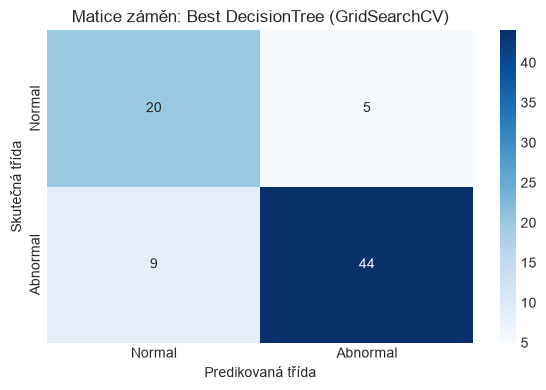

In [4]:
# Vyhodnocení nejlepšího modelu na nezávislé testovací sadě
best_dt = grid_search.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print("Classification Report pro nejlepší DecisionTree z GridSearchCV:")
print(classification_report(y_test, y_pred_dt, target_names=['Normal (0)', 'Abnormal (1)']))

# Matice záměn
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title("Matice záměn: Best DecisionTree (GridSearchCV)")
plt.xlabel("Predikovaná třída")
plt.ylabel("Skutečná třída")
plt.tight_layout()
plt.show()

## 2. Randomized Search: `RandomizedSearchCV` (Support Vector Machine - SVC)
Pro Support Vector Machine s RBF a lineárním jádrem náhodně vzorkujeme parametry ze spojitých rovnoměrných rozdělení:
- $C \sim \text{Uniform}(0.01, 4.01)$
- $\gamma \sim \text{Uniform}(0.001, 0.101)$
- `kernel`: 'rbf', 'linear'
- Optimalizovaná metrika: `scoring='precision'`
- Počet náhodných pokusů: `n_iter=20`


In [5]:
param_dist = {
    'C': uniform(loc=0.01, scale=4.0),
    'gamma': uniform(loc=0.001, scale=0.1),
    'kernel': ['rbf', 'linear']
}

model_svc = SVC(random_state=42)
random_search = RandomizedSearchCV(
    estimator=model_svc,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="precision",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Nejlepší nalezené parametry pro SVC:")
print(random_search.best_params_)
print(f"Nejlepší průměrná validační Precision (5-Fold CV): {random_search.best_score_:.4f}")

Nejlepší nalezené parametry pro SVC:
{'C': 3.9050220753658365, 'gamma': 0.024277134043030425, 'kernel': 'linear'}
Nejlepší průměrná validační Precision (5-Fold CV): 0.9244


Classification Report pro nejlepší SVC z RandomizedSearchCV:
              precision    recall  f1-score   support

  Normal (0)       0.67      0.96      0.79        25
Abnormal (1)       0.98      0.77      0.86        53

    accuracy                           0.83        78
   macro avg       0.82      0.87      0.83        78
weighted avg       0.88      0.83      0.84        78



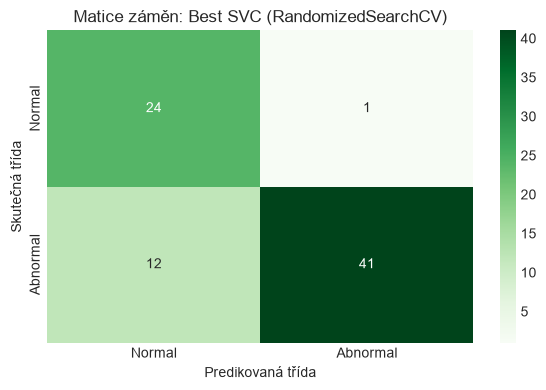

In [6]:
best_svc = random_search.best_estimator_
y_pred_svc = best_svc.predict(X_test)

print("Classification Report pro nejlepší SVC z RandomizedSearchCV:")
print(classification_report(y_test, y_pred_svc, target_names=['Normal (0)', 'Abnormal (1)']))

# Matice záměn
cm_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Greens', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title("Matice záměn: Best SVC (RandomizedSearchCV)")
plt.xlabel("Predikovaná třída")
plt.ylabel("Skutečná třída")
plt.tight_layout()
plt.show()

## 3. Bayesovská optimalizace: `hyperopt` (TPE)
Využijeme pokročilý Bayesovský optimalizátor Tree-structured Parzen Estimator (TPE):
- Definujeme vyhledávací prostor pomocí `hp.choice` a `hp.uniform`.
- Cílová funkce vrací záporné skóre `return -scores.mean()`, protože `fmin` minimalizuje ztrátu.
- Sledujeme historii pokusů pomocí objektu `Trials()`.


In [7]:
space = {
    'min_samples_split': hp.uniform('min_samples_split', 5, 25),
    'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 15, 20, 25, 30]),
    'max_depth': hp.choice('max_depth', [None, 3, 5, 7, 10]),
    'criterion': hp.choice('criterion', ['gini', 'entropy'])
}

def objective(params):
    clf = DecisionTreeClassifier(
        min_samples_split=int(params['min_samples_split']),
        min_samples_leaf=int(params['min_samples_leaf']),
        max_depth=params['max_depth'],
        criterion=params['criterion'],
        random_state=42
    )
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="recall", n_jobs=-1)
    return -scores.mean()

trials = Trials()
max_evals = 35

best_raw = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=max_evals,
    trials=trials,
    rstate=np.random.default_rng(42)
)

best_bayes_params = space_eval(space, best_raw)
print("Nejlepší nalezené parametry pomocí Hyperopt:")
print(best_bayes_params)

  0%|          | 0/35 [00:00<?, ?trial/s, best loss=?]

 23%|██▎       | 8/35 [00:00<00:00, 74.08trial/s, best loss: -0.8538306451612904]

 46%|████▌     | 16/35 [00:00<00:00, 74.37trial/s, best loss: -0.8538306451612904]

 69%|██████▊   | 24/35 [00:00<00:00, 73.26trial/s, best loss: -0.8911290322580646]

 91%|█████████▏| 32/35 [00:00<00:00, 71.68trial/s, best loss: -0.8911290322580646]

100%|██████████| 35/35 [00:00<00:00, 72.05trial/s, best loss: -0.8911290322580646]


Nejlepší nalezené parametry pomocí Hyperopt:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 30, 'min_samples_split': 22.64535209949264}


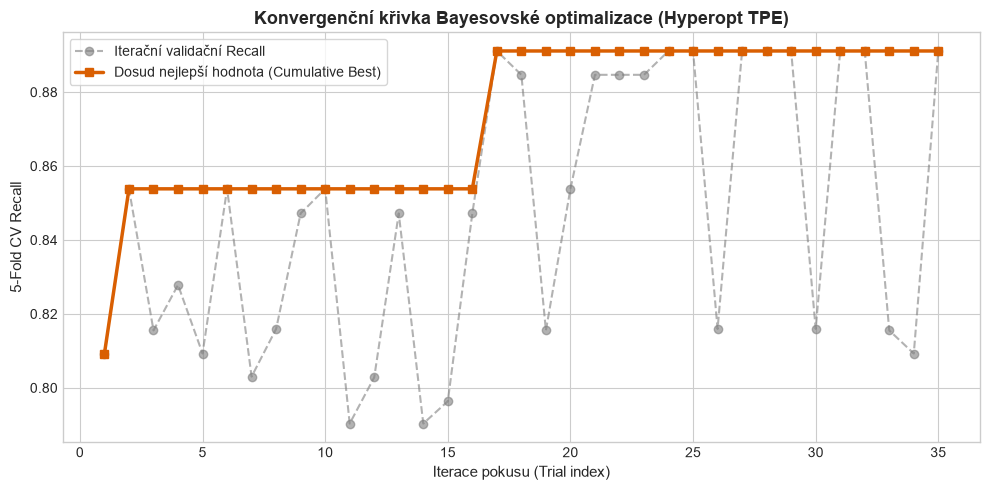

In [8]:
# Vykreslení křivky konvergence TPE
history_losses = [-t['result']['loss'] for t in trials.trials]
cum_max = np.maximum.accumulate(history_losses)

plt.figure(figsize=(10, 5))
plt.plot(range(1, max_evals + 1), history_losses, marker='o', linestyle='--', color='gray', alpha=0.6, label='Iterační validační Recall')
plt.plot(range(1, max_evals + 1), cum_max, marker='s', linewidth=2.5, color='#d95f02', label='Dosud nejlepší hodnota (Cumulative Best)')
plt.title("Konvergenční křivka Bayesovské optimalizace (Hyperopt TPE)", fontsize=13, fontweight='bold')
plt.xlabel("Iterace pokusu (Trial index)", fontsize=11)
plt.ylabel("5-Fold CV Recall", fontsize=11)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

## 4. Shrnutí výsledků a srovnání metod
Každá metoda má v reálném datovém projektu své opodstatnění:
- **`GridSearchCV`:** Skvělý pro konečný malý prostor parametrů (1–2 parametry) s přesně zadanými diskrétními hodnotami.
- **`RandomizedSearchCV`:** První volba pro 3+ parametrů s neznámým rozsahem – rychle prozkoumá prostor bez kombinatorické exploze.
- **`Hyperopt`:** Nejvýkonnější přístup pro složité modely s drahým tréninkem (GBDT, XGBoost, neuronové sítě), kde každý pokus těží ze zkušeností předchozích pokusů.
